In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import shutil
import pandas as pd
import seaborn as sns
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Copy dataset từ Drive sang /content/ để training nhanh hơn với GPU T4
drive_path = '/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/datasets/vietnamese-foods.zip'
local_path = '/content/vietnamese-foods.zip'






In [ ]:
# Unzip
!unzip -q /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/datasets/vietnamese-foods.zip -d "/content/30VNFoods"

In [ ]:
#sao chép dataset vào bộ nhớ cục bộ của colab
shutil.copy(drive_path, local_path)

'/content/vietnamese-foods.zip'

In [ ]:
# Unzip
!unzip -q /content/vietnamese-foods.zip -d "/content/30VNFoods"

In [ ]:
data_path = Path("/content/30VNFoods/Images/Train")

class_folders = sorted([f for f in data_path.iterdir() if f.is_dir()])
print(f"Số lượng món: {len(class_folders)}")



Số lượng món: 30


In [ ]:
class_names = list(train_gen.class_indices.keys())
print(class_names)

['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


In [ ]:
# 1. Class distribution chi tiết
class_counts = {}
for folder in class_folders:
    class_name = folder.name
    num_images = len(list(folder.glob('*.jpg')))  # Thêm *.jpeg nếu cần
    class_counts[class_name] = num_images

In [ ]:
df_counts = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Số lượng ảnh'])

In [ ]:
df_counts = df_counts.sort_values('Số lượng ảnh', ascending=False)

In [ ]:
print("Phân bố số lượng ảnh theo class (sắp xếp giảm dần):")
print(df_counts)

Phân bố số lượng ảnh theo class (sắp xếp giảm dần):
                  Số lượng ảnh
Bun bo Hue                1071
Banh mi                    935
Banh xeo                   821
Bun rieu                   805
Banh cuon                  798
Chao long                  751
Hu tieu                    688
Banh canh                  674
Com tam                    659
Bun dau mam tom            640
Mi quang                   618
Goi cuon                   598
Banh khot                  584
Canh chua                  577
Pho                        564
Banh trang nuong           556
Bun mam                    541
Bun thit nuong             522
Banh can                   520
Banh bot loc               503
Banh tet                   480
Ca kho to                  473
Banh duc                   463
Banh beo                   451
Banh gio                   448
Cao lau                    432
Nem chua                   379
Xoi xeo                    366
Banh chung                 354
Banh pia          

/tmp/ipython-input-2022842242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['Số lượng ảnh'], palette='viridis')


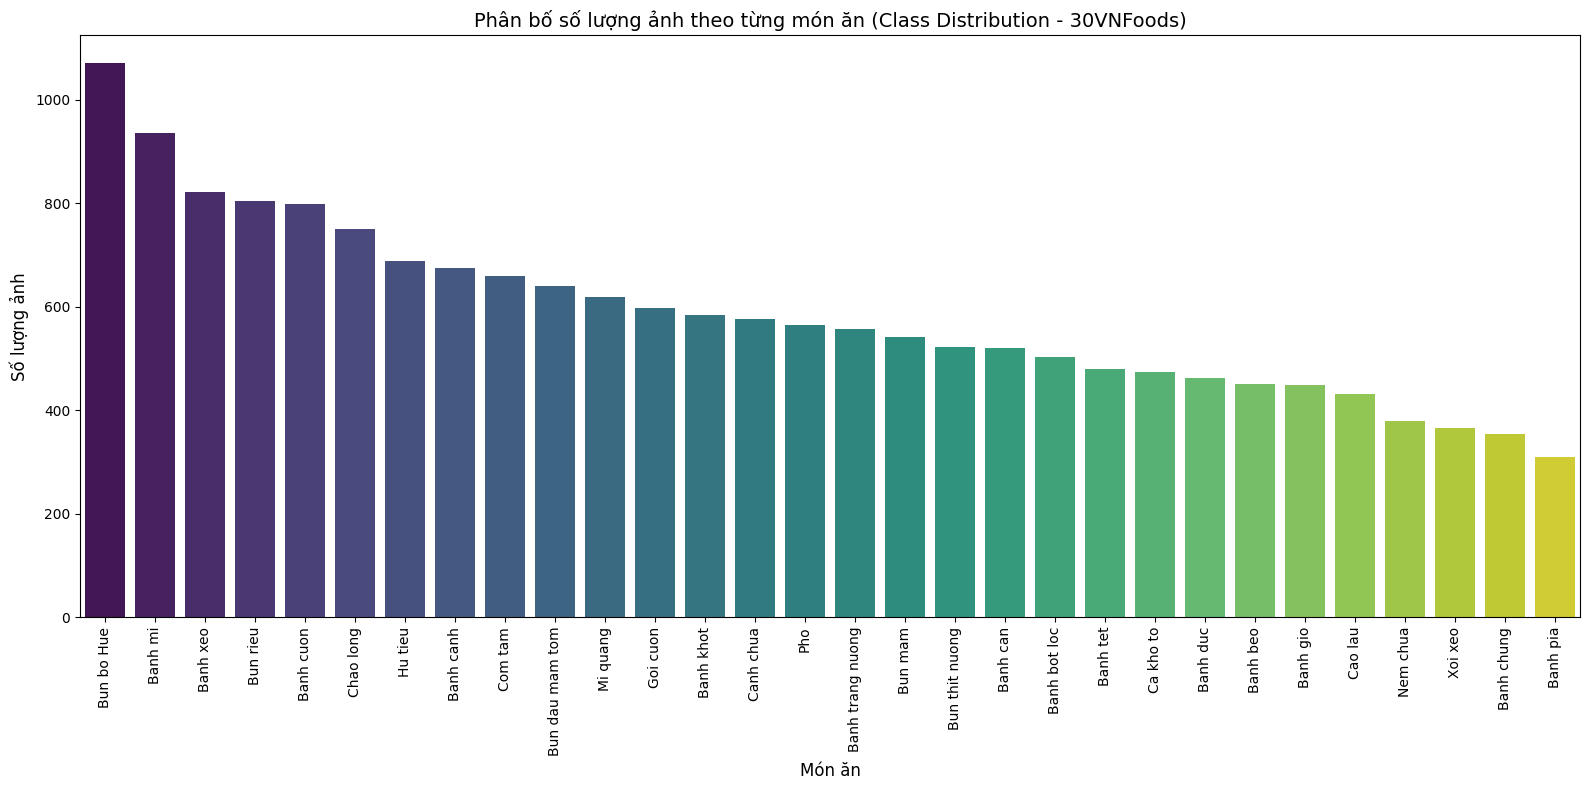

In [ ]:
# Bar chart đẹp hơn
plt.figure(figsize=(16, 8))
sns.barplot(x=df_counts.index, y=df_counts['Số lượng ảnh'], palette='viridis')
plt.xticks(rotation=90, fontsize=10)
plt.title('Phân bố số lượng ảnh theo từng món ăn (Class Distribution - 30VNFoods)', fontsize=14)
plt.xlabel('Món ăn', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
base = Path('/content/30VNFoods/Images')
splits = ['Train', 'Validate', 'Test']

classes = sorted([d.name for d in (base/'Train').iterdir() if d.is_dir()])

rows = []
for cls in classes:
    counts = [len(list((base/split/cls).glob('*.jp*g'))) for split in splits]
    rows.append([cls.replace('_',' ').title()] + counts + [sum(counts)])

df = pd.DataFrame(rows, columns=['Lớp món ăn', 'Train', 'Validation', 'Test', 'Tổng cộng'])
df = pd.concat([df.sort_values('Tổng cộng', ascending=False),
                pd.DataFrame([['Tổng'] + df.iloc[:,1:].sum().tolist()], columns=df.columns)],
               ignore_index=True)

print(df.to_string(index=False))

      Lớp món ăn  Train  Validation  Test  Tổng cộng
      Bun Bo Hue   1071         153   306       1530
         Banh Mi    935         133   268       1336
        Banh Xeo    821         117   235       1173
        Bun Rieu    805         115   231       1151
       Banh Cuon    798         114   228       1140
       Chao Long    751         107   215       1073
         Hu Tieu    688          98   197        983
       Banh Canh    674          97   193        964
         Com Tam    659          94   189        942
 Bun Dau Mam Tom    640          92   184        916
        Mi Quang    618          89   177        884
        Goi Cuon    598          85   172        855
       Banh Khot    584          84   167        835
       Canh Chua    577          83   165        825
             Pho    564          81   162        807
Banh Trang Nuong    556          80   159        795
         Bun Mam    541          77   155        773
  Bun Thit Nuong    522          75   150     

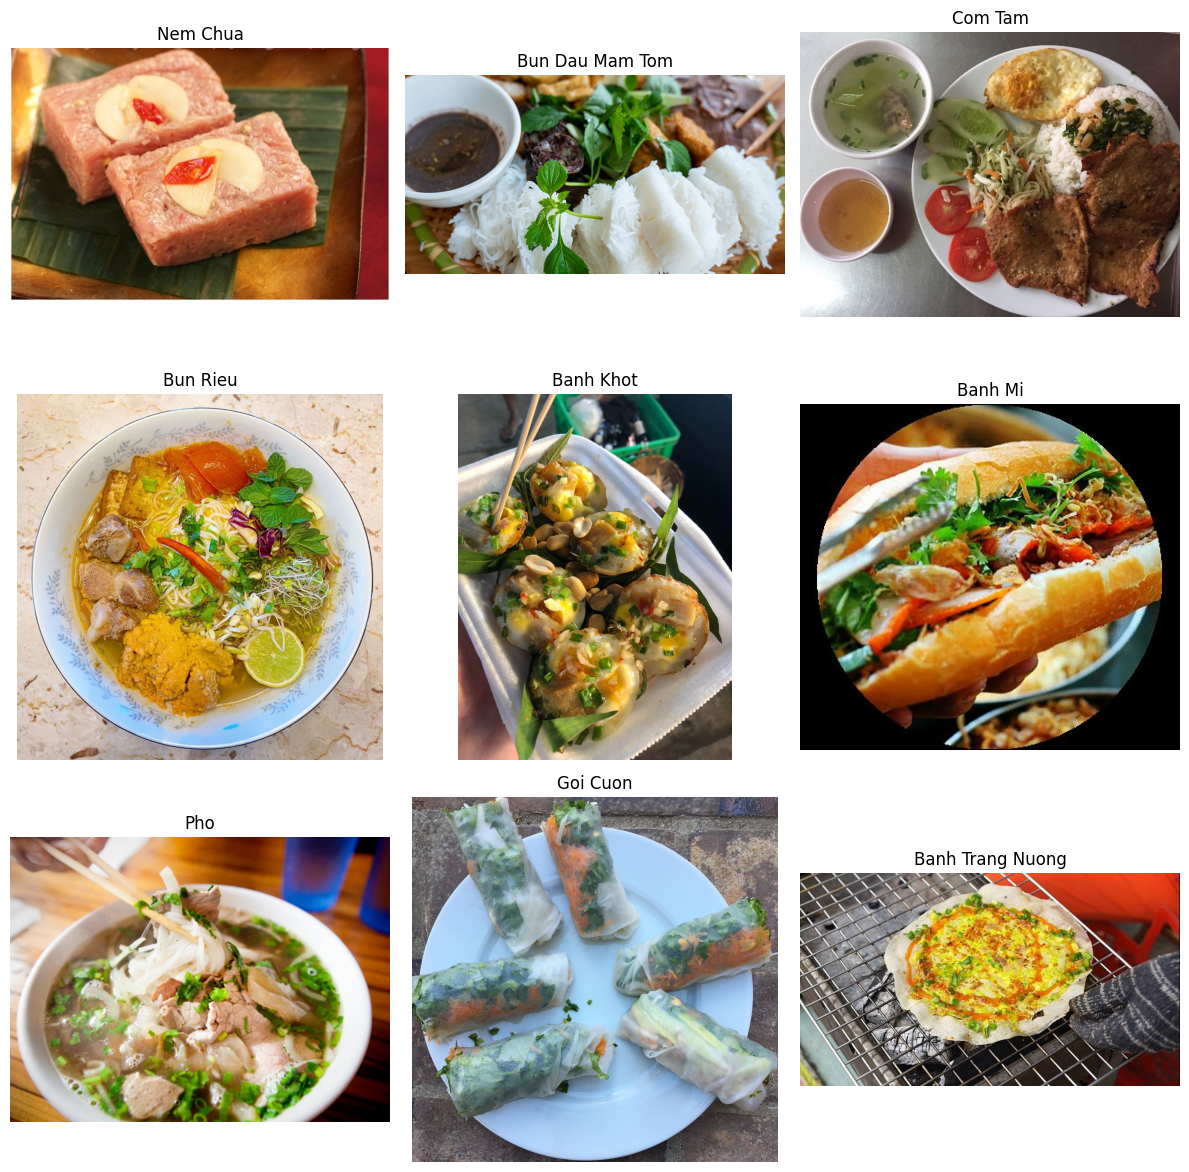

In [ ]:
# Hiển thị một số ảnh mẫu
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()
for idx, folder in enumerate(np.random.choice(class_folders, 9, replace=False)):
    imgs = list(folder.glob('*.jpg'))
    if imgs:
        img = Image.open(np.random.choice(imgs))
        axes[idx].imshow(img)
        axes[idx].set_title(folder.name.replace('_', ' ').title())
        axes[idx].axis('off')
plt.tight_layout()
plt.show()

Tiền xử lý dữ liệu


Chúng ta resize ảnh về 224×224 pixels và áp dụng data augmentation (xoay, lật, zoom) để tăng đa dạng dữ liệu training. Các ảnh cũng được normalize theo statistics của ImageNet vì ResNet-50 được pretrain trên ImageNet.


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 30



In [ ]:
# Data augmentation cho training set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
train_gen = train_datagen.flow_from_directory(
    '/content/30VNFoods/Images/Train', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
print(f"Số lượng mẫu cho train: {train_gen.samples}")

Found 17581 images belonging to 30 classes.
Số lượng mẫu cho train: 17581


In [ ]:
train_gen.class_indices

{'Banh beo': 0,
 'Banh bot loc': 1,
 'Banh can': 2,
 'Banh canh': 3,
 'Banh chung': 4,
 'Banh cuon': 5,
 'Banh duc': 6,
 'Banh gio': 7,
 'Banh khot': 8,
 'Banh mi': 9,
 'Banh pia': 10,
 'Banh tet': 11,
 'Banh trang nuong': 12,
 'Banh xeo': 13,
 'Bun bo Hue': 14,
 'Bun dau mam tom': 15,
 'Bun mam': 16,
 'Bun rieu': 17,
 'Bun thit nuong': 18,
 'Ca kho to': 19,
 'Canh chua': 20,
 'Cao lau': 21,
 'Chao long': 22,
 'Com tam': 23,
 'Goi cuon': 24,
 'Hu tieu': 25,
 'Mi quang': 26,
 'Nem chua': 27,
 'Pho': 28,
 'Xoi xeo': 29}

In [ ]:
# Chỉ rescale cho validation set
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,)
val_gen = val_datagen.flow_from_directory(
    '/content/30VNFoods/Images/Validate', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=42
)
print(f"Số lượng mẫu cho valuate: {val_gen.samples}")

Found 2515 images belonging to 30 classes.
Số lượng mẫu cho valuate: 2515


In [ ]:
# Tạo test generator tương tự validation
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,)
test_gen = test_datagen.flow_from_directory(
    '/content/30VNFoods/Images/Test', target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, seed=42
)
print(f"Số lượng mẫu cho test: {test_gen.samples}")

Found 5040 images belonging to 30 classes.
Số lượng mẫu cho test: 5040


Huấn luyện: ResNet-50


Chúng ta sẽ finetune ResNet-50 pretrained trên ImageNet. ResNet từ bài báo "Deep Residual Learning for Image Recognition" là một trong những kiến trúc tốt nhất cho computer vision.
Chúng ta train theo hai giai đoạn:

Freeze ResNet-50 và chỉ train classification head
Unfreeze và finetune toàn bộ mạng với learning rate nhỏ hơn

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)




94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Model(inputs=base_model.input, outputs=predictions)


In [ ]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks
callbacks = [
    ModelCheckpoint('stage1.h5', monitor='val_accuracy',
                   save_best_only=True, mode='max'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

In [ ]:
# Train Stage 1
history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2838 - loss: 2.6479

275/275 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.2841 - loss: 2.6461 - val_accuracy: 0.5905 - val_loss: 1.3906 - learning_rate: 0.0010
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5226 - loss: 1.5908

275/275 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.5226 - loss: 1.5906 - val_accuracy: 0.6457 - val_loss: 1.2163 - learning_rate: 0.0010
Epoch 3/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5794 - loss: 1.3944

275/275 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.5794 - loss: 1.3944 - val_accuracy: 0.6509 - val_loss: 1.1677 - learning_rate: 0.0010
Epoch 4/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5987 - loss: 1.3104

275/275 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.5986 - loss: 1.3105 - val_accuracy: 0.6553 - val_loss: 1.1478 - learning_rate: 0.0010
Epoch 5/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6145 - loss: 1.2602

...

275/275 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.6256 - loss: 1.2256 - val_accuracy: 0.6875 - val_loss: 1.0692 - learning_rate: 0.0010
Epoch 7/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.6346 - loss: 1.1960 - val_accuracy: 0.6835 - val_loss: 1.0823 - learning_rate: 0.0010
Epoch 8/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.6412 - loss: 1.1694 - val_accuracy: 0.6803 - val_loss: 1.0585 - learning_rate: 0.0010
Epoch 9/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.6497 - loss: 1.1521 - val_accuracy: 0.6795 - val_loss: 1.0535 - learning_rate: 0.0010
Epoch 10/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.6614 - loss: 1.0998 - val_accuracy: 0.6855 - val_loss: 1.0725 - learning_rate: 0.0010
Epoch 11/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6584 - loss: 1.1130

275/275 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.6584 - loss: 1.1130 - val_accuracy: 0.6899 - val_loss: 1.0506 - learning_rate: 0.0010
Epoch 12/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6764 - loss: 1.0779

275/275 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.6764 - loss: 1.0779 - val_accuracy: 0.6907 - val_loss: 1.0511 - learning_rate: 0.0010
Epoch 13/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6710 - loss: 1.0431

275/275 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.6710 - loss: 1.0431 - val_accuracy: 0.7109 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 14/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.6808 - loss: 1.0261 - val_accuracy: 0.6966 - val_loss: 1.0347 - learning_rate: 0.0010
Epoch 15/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.6863 - loss: 1.0092 - val_accuracy: 0.6974 - val_loss: 1.0266 - learning_rate: 0.0010
Epoch 16/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.6848 - loss: 1.0008 - val_accuracy: 0.7082 - val_loss: 1.0014 - learning_rate: 0.0010
Epoch 17/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6897 - loss: 1.0003

275/275 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.6897 - loss: 1.0003 - val_accuracy: 0.7117 - val_loss: 0.9946 - learning_rate: 0.0010
Epoch 18/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.6971 - loss: 0.9714 - val_accuracy: 0.7105 - val_loss: 0.9996 - learning_rate: 0.0010
Epoch 19/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.6908 - loss: 0.9928 - val_accuracy: 0.7030 - val_loss: 1.0055 - learning_rate: 0.0010
Epoch 20/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.6997 - loss: 0.9597 - val_accuracy: 0.7070 - val_loss: 1.0095 - learning_rate: 0.0010


In [ ]:
model_path = "/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models"

In [ ]:
import shutil
shutil.copy(
    "stage1.h5",
    f"{model_path}/stage1.h5")

'/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/stage1.h5'

In [ ]:
model.save(f'{model_path}/resnet_50_stage1.h5')

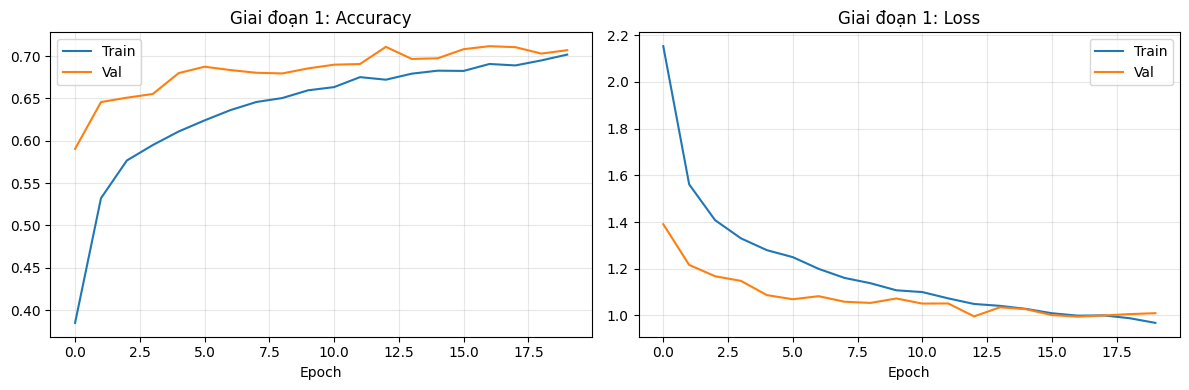

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history1.history['accuracy'], label='Train')
ax1.plot(history1.history['val_accuracy'], label='Val')
ax1.set_title('Giai đoạn 1: Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history1.history['loss'], label='Train')
ax2.plot(history1.history['val_loss'], label='Val')
ax2.set_title('Giai đoạn 1: Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Unfreeze
model.load_weights(f"{model_path}/stage1.h5")
base_model.trainable = True

In [ ]:
# Chỉ train 30 layers cuối
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
# Compile với learning rate nhỏ hơn 10 lần
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks2 = [
    ModelCheckpoint(f"{model_path}/stage2.h5", monitor='val_accuracy',
                   save_best_only=True, mode='max'),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8)
]

In [ ]:
# Train Stage 2
history2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks2
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6603 - loss: 1.1566

275/275 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.6605 - loss: 1.1560 - val_accuracy: 0.7455 - val_loss: 0.8897 - learning_rate: 1.0000e-04
Epoch 2/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7794 - loss: 0.7139

275/275 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.7794 - loss: 0.7140 - val_accuracy: 0.7555 - val_loss: 0.8668 - learning_rate: 1.0000e-04
Epoch 3/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8164 - loss: 0.5942

275/275 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.8164 - loss: 0.5943 - val_accuracy: 0.7718 - val_loss: 0.8680 - learning_rate: 1.0000e-04
Epoch 4/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.8375 - loss: 0.5120 - val_accuracy: 0.7634 - val_loss: 0.8647 - learning_rate: 1.0000e-04
Epoch 5/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8591 - loss: 0.4437

...

275/275 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.8740 - loss: 0.3980 - val_accuracy: 0.7905 - val_loss: 0.8480 - learning_rate: 1.0000e-04
Epoch 7/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8867 - loss: 0.3619

275/275 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.8867 - loss: 0.3619 - val_accuracy: 0.7913 - val_loss: 0.8367 - learning_rate: 1.0000e-04
Epoch 8/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.9025 - loss: 0.3081 - val_accuracy: 0.7718 - val_loss: 0.9583 - learning_rate: 1.0000e-04
Epoch 9/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9097 - loss: 0.2839

275/275 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.9097 - loss: 0.2840 - val_accuracy: 0.7968 - val_loss: 0.8947 - learning_rate: 1.0000e-04
Epoch 10/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.9268 - loss: 0.2416 - val_accuracy: 0.7905 - val_loss: 0.9516 - learning_rate: 1.0000e-04
Epoch 11/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.9357 - loss: 0.2048 - val_accuracy: 0.7964 - val_loss: 0.8945 - learning_rate: 5.0000e-05
Epoch 12/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9523 - loss: 0.1563

275/275 ━━━━━━━━━━━━━━━━━━━━ 444s 1s/step - accuracy: 0.9522 - loss: 0.1564 - val_accuracy: 0.8139 - val_loss: 0.9038 - learning_rate: 5.0000e-05
Epoch 13/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.9559 - loss: 0.1473 - val_accuracy: 0.8103 - val_loss: 0.9177 - learning_rate: 5.0000e-05
Epoch 14/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9622 - loss: 0.1205

275/275 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9622 - loss: 0.1205 - val_accuracy: 0.8187 - val_loss: 0.9035 - learning_rate: 2.5000e-05
Epoch 15/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.9654 - loss: 0.1122 - val_accuracy: 0.8091 - val_loss: 0.9578 - learning_rate: 2.5000e-05


In [ ]:
model.save(f"{model_path}/final_model.h5")

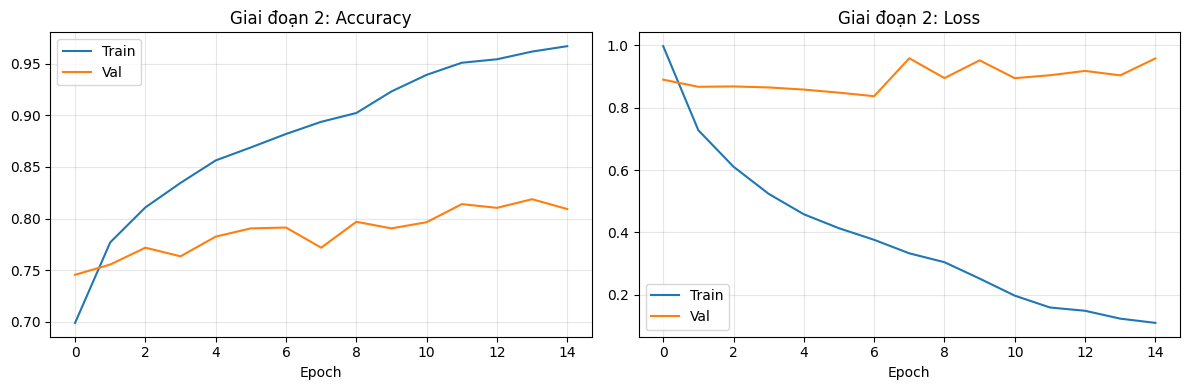

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history2.history['accuracy'], label='Train')
ax1.plot(history2.history['val_accuracy'], label='Val')
ax1.set_title('Giai đoạn 2: Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history2.history['loss'], label='Train')
ax2.plot(history2.history['val_loss'], label='Val')
ax2.set_title('Giai đoạn 2: Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Load model tốt nhất
model.load_weights(f"{model_path}/stage2.h5")




In [ ]:
# Đánh giá trên tập test
test_results = model.evaluate(test_gen)
print(f"Độ chính xác trên tập test : {test_results[1]*100:.2f}%")






79/79 ━━━━━━━━━━━━━━━━━━━━ 65s 820ms/step - accuracy: 0.7966 - loss: 0.9788
Độ chính xác trên tập test : 82.10%


In [ ]:
# Predictions on test set
test_gen.reset()
y_test_pred = model.predict(test_gen, steps=len(test_gen))
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true = test_gen.classes[:len(y_test_pred_classes)]

79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 803ms/step


In [ ]:
print("\nBáo cáo phân loại :")
print(classification_report(y_test_true, y_test_pred_classes,
                          target_names=[n.replace('_',' ').title() for n in class_names]))


Báo cáo phân loại :
                  precision    recall  f1-score   support

        Banh Beo       0.93      0.74      0.83       129
    Banh Bot Loc       0.70      0.79      0.75       144
        Banh Can       0.90      0.79      0.84       149
       Banh Canh       0.71      0.54      0.61       193
      Banh Chung       0.84      0.86      0.85       102
       Banh Cuon       0.77      0.81      0.79       228
        Banh Duc       0.65      0.62      0.64       133
        Banh Gio       0.78      0.89      0.83       129
       Banh Khot       0.88      0.88      0.88       167
         Banh Mi       0.95      0.96      0.96       268
        Banh Pia       0.90      0.96      0.93        89
        Banh Tet       0.89      0.81      0.85       138
Banh Trang Nuong       0.92      0.83      0.87       159
        Banh Xeo       0.92      0.87      0.89       235
      Bun Bo Hue       0.65      0.82      0.72       306
 Bun Dau Mam Tom       0.95      0.97      0.96   

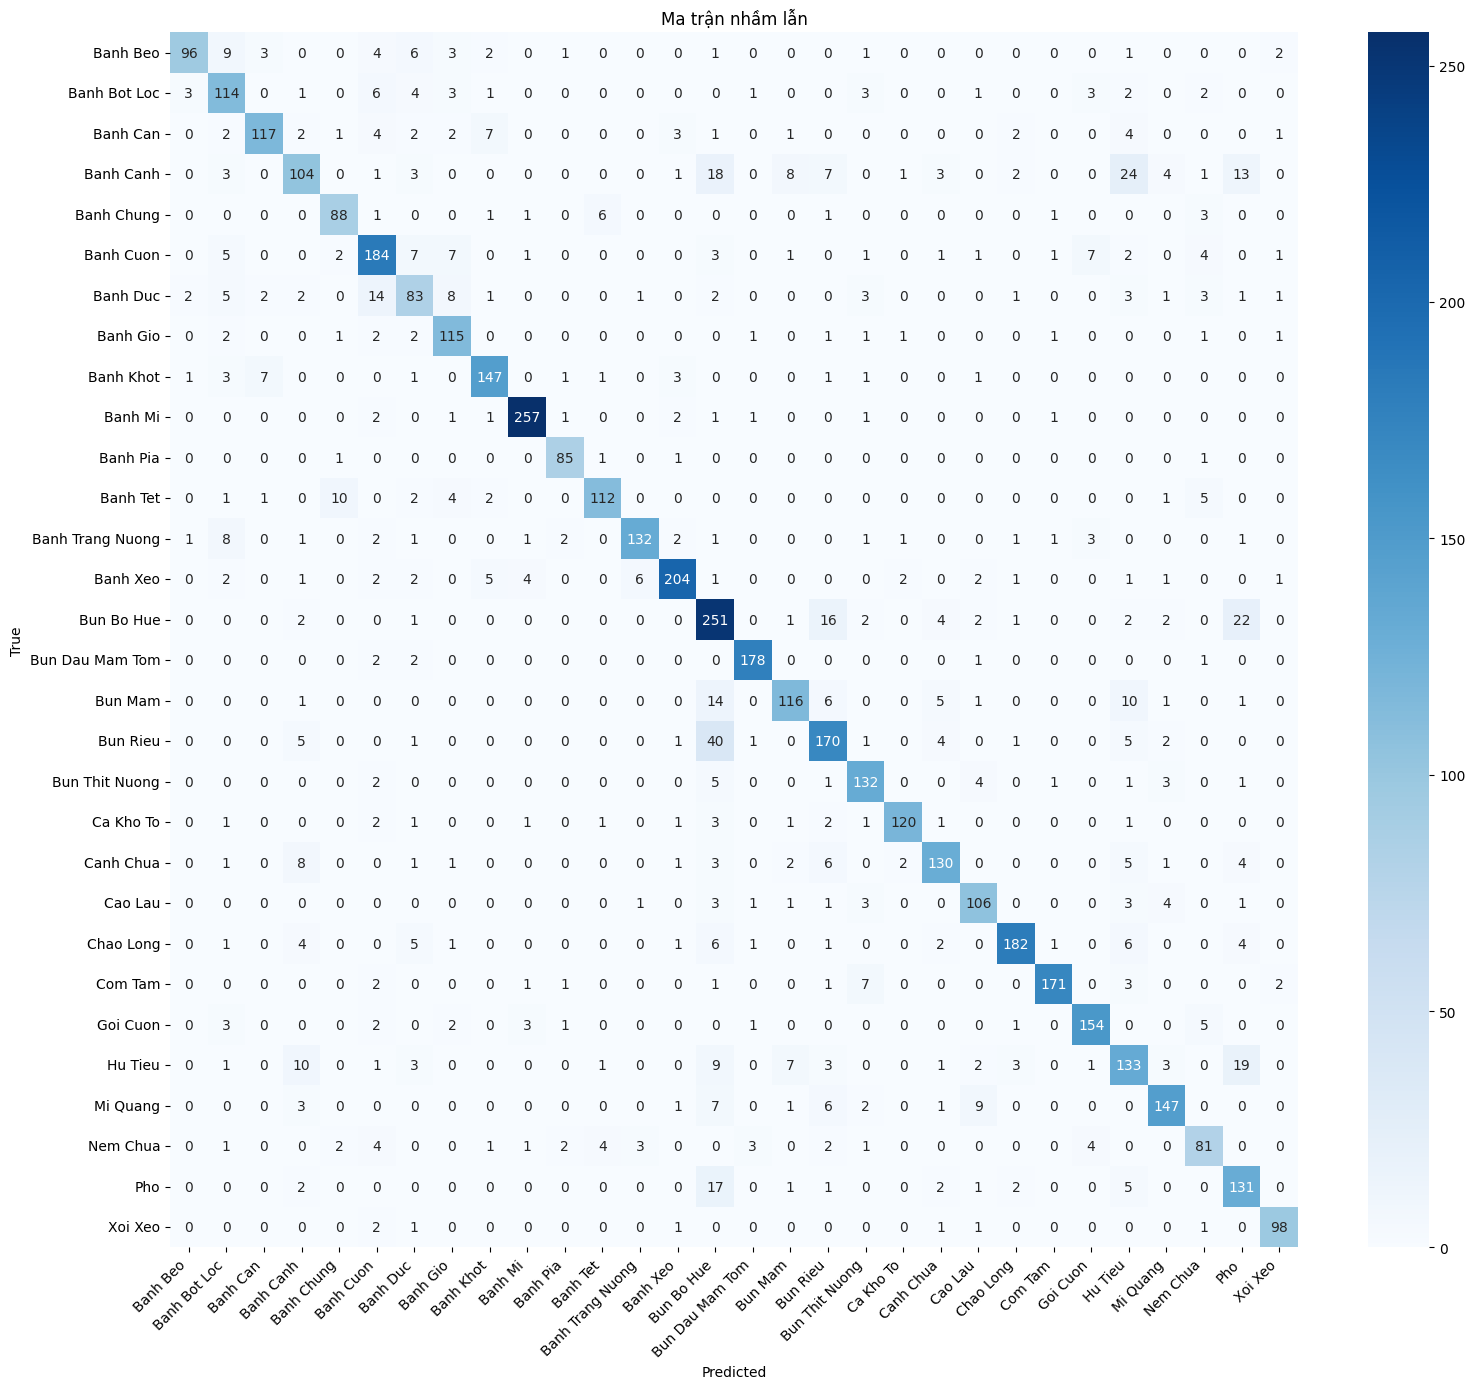

In [ ]:
# Confusion Matrix for test set
cm_test = confusion_matrix(y_test_true, y_test_pred_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
           xticklabels=[n.replace('_',' ').title() for n in class_names],
           yticklabels=[n.replace('_',' ').title() for n in class_names])
plt.title('Ma trận nhầm lẫn')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate
results = model.evaluate(val_gen)
print(f"Độ chính xác trên tập val: {results[1]*100:.2f}%")

40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 887ms/step - accuracy: 0.8072 - loss: 1.0285
Độ chính xác trên tập val: 81.87%


In [ ]:
# Predictions
val_gen.reset()
y_pred = model.predict(val_gen, steps=len(val_gen))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes[:len(y_pred_classes)]

40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 740ms/step


In [ ]:
# Classification report
class_names = list(val_gen.class_indices.keys())
print("\n Báo cáo phân loại :")
print(classification_report(y_true, y_pred_classes,
                          target_names=[n.replace('_',' ').title() for n in class_names]))


 Báo cáo phân loại :
                  precision    recall  f1-score   support

        Banh Beo       0.93      0.83      0.88        65
    Banh Bot Loc       0.64      0.74      0.68        73
        Banh Can       0.91      0.91      0.91        75
       Banh Canh       0.72      0.55      0.62        97
      Banh Chung       0.75      0.80      0.78        50
       Banh Cuon       0.89      0.84      0.86       114
        Banh Duc       0.64      0.55      0.59        66
        Banh Gio       0.82      0.91      0.86        64
       Banh Khot       0.88      0.83      0.85        84
         Banh Mi       0.91      0.94      0.92       133
        Banh Pia       0.93      0.89      0.91        45
        Banh Tet       0.82      0.79      0.81        68
Banh Trang Nuong       0.97      0.89      0.93        80
        Banh Xeo       0.93      0.88      0.90       117
      Bun Bo Hue       0.68      0.84      0.75       153
 Bun Dau Mam Tom       0.91      1.00      0.95  

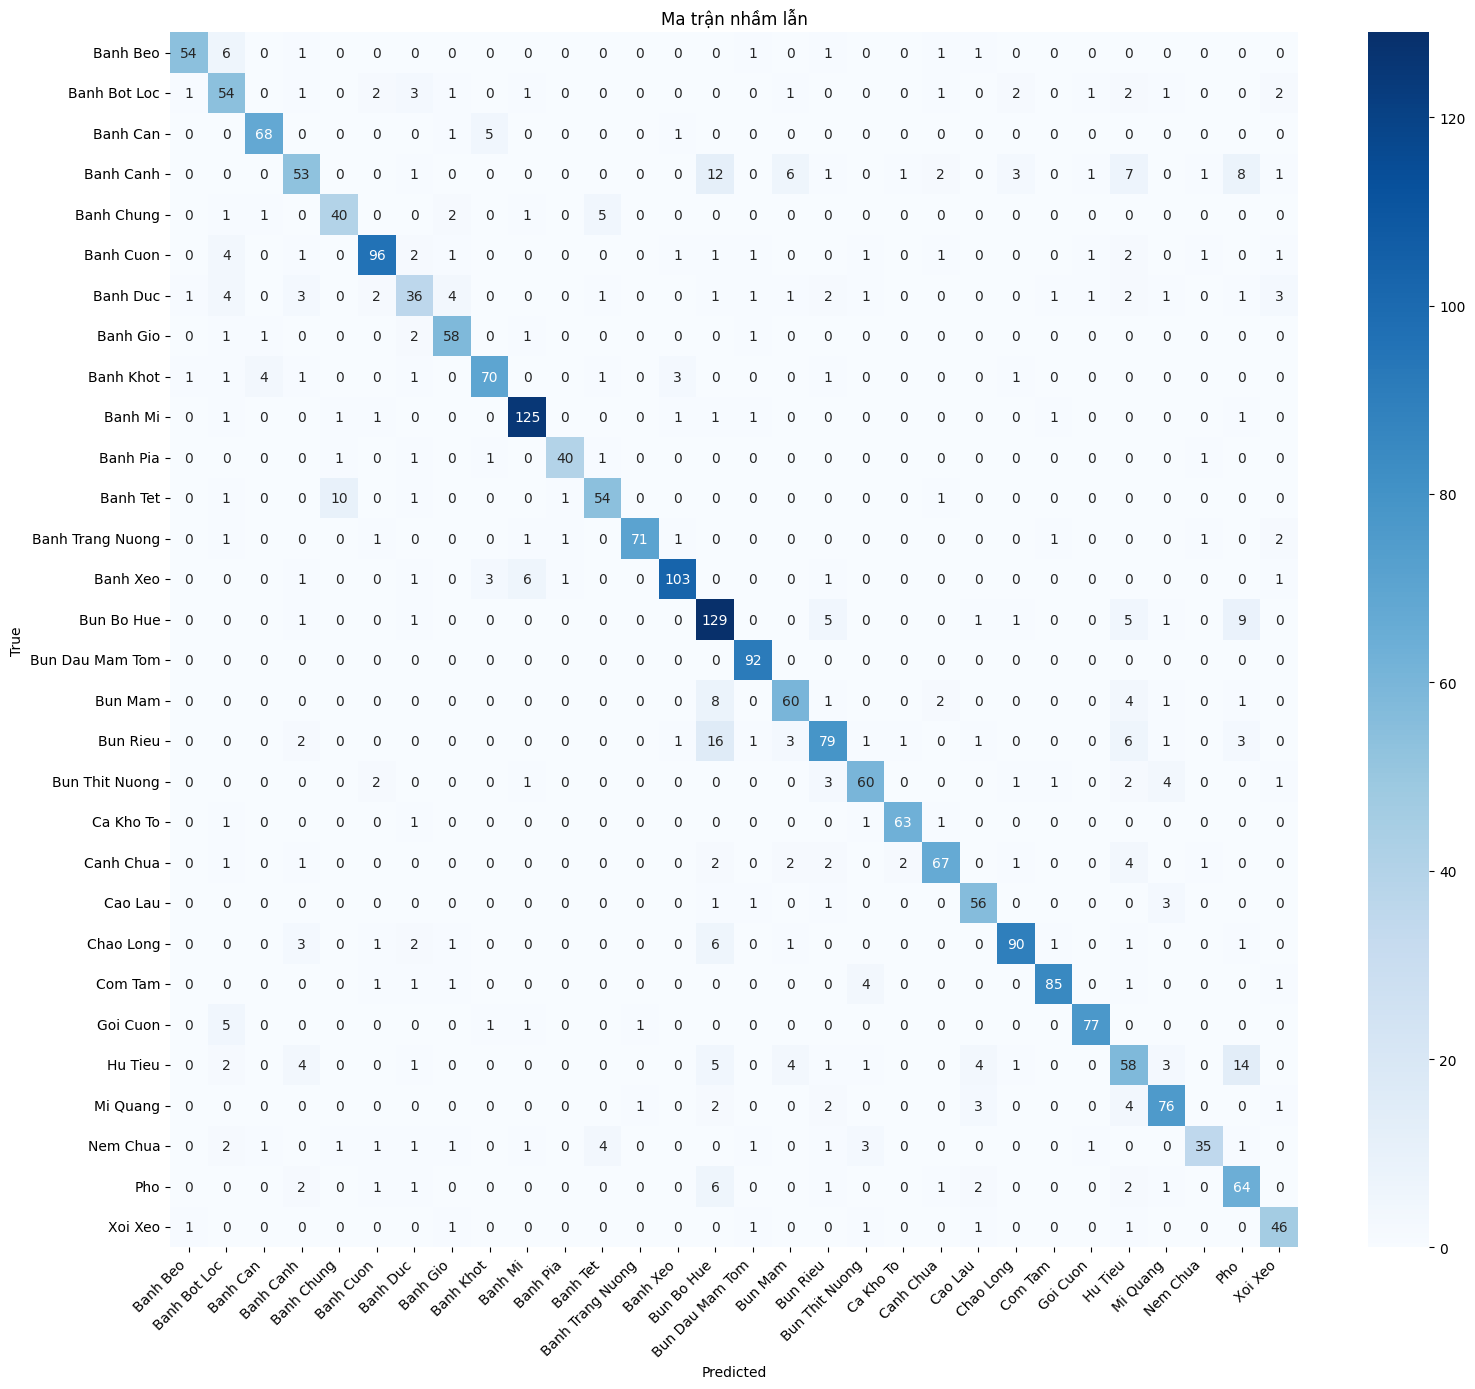

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=[n.replace('_',' ').title() for n in class_names],
           yticklabels=[n.replace('_',' ').title() for n in class_names])
plt.title('Ma trận nhầm lẫn')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

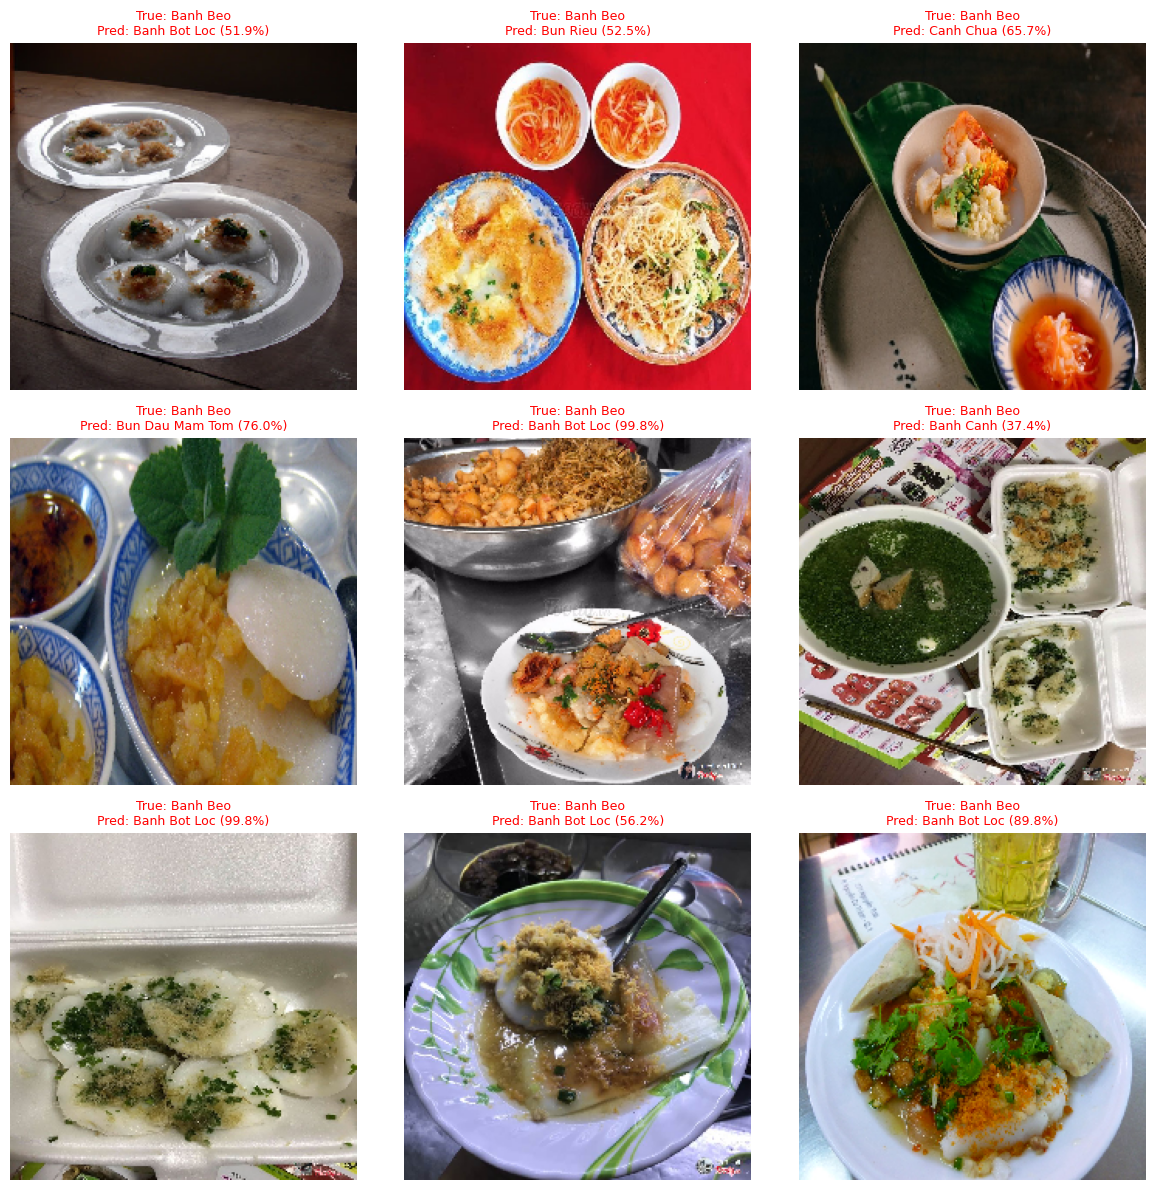

In [ ]:
# Tìm những ảnh bị phân loại sai
wrong_idx = np.where(y_pred_classes != y_true)[0][:9]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()
for i, idx in enumerate(wrong_idx):
    img = load_img(val_gen.filepaths[idx], target_size=(IMG_SIZE, IMG_SIZE))

    true_label = class_names[y_true[idx]].replace('_',' ').title()
    pred_label = class_names[y_pred_classes[idx]].replace('_',' ').title()
    confidence = y_pred[idx][y_pred_classes[idx]] * 100

    axes[i].imshow(img)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                     color='red', fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Tìm most confused pairs
confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            confused_pairs.append((class_names[i], class_names[j], cm[i][j]))
confused_pairs.sort(key=lambda x: x[2], reverse=True)
print("Top 10 cặp dễ nhầm lẫn:")
for true_cls, pred_cls, count in confused_pairs[:10]:
    print(f"{true_cls.replace('_',' ').title()} → {pred_cls.replace('_',' ').title()}: {count}")

Top 10 cặp dễ nhầm lẫn:
Bun Rieu → Bun Bo Hue: 16
Hu Tieu → Pho: 14
Banh Canh → Bun Bo Hue: 12
Banh Tet → Banh Chung: 10
Bun Bo Hue → Pho: 9
Banh Canh → Pho: 8
Bun Mam → Bun Bo Hue: 8
Banh Canh → Hu Tieu: 7
Banh Beo → Banh Bot Loc: 6
Banh Canh → Bun Mam: 6


In [ ]:
class_names = list(train_gen.class_indices.keys())
print(class_names)

['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


In [ ]:
import os
from pathlib import Path
import json
import pandas as pd

In [ ]:
dataset_root = Path('/content/30VNFoods/Images')
if not dataset_root.exists():
    print("Dataset chưa tồn tại! Cần unzip lại trước khi tạo metadata.")
    print("Chạy lại các cell unzip sau đây:")
    print("!unzip -q /content/drive/MyDrive/.../vietnamese-foods.zip -d /content/30VNFoods")

else:
    print("Dataset tồn tại")

Dataset tồn tại


In [ ]:
splits = {
    'train': dataset_root / 'Train',
    'validation': dataset_root / 'Validate',
    'test': dataset_root / 'Test'
}

In [ ]:
metadata = {
    "dataset_name": "30 Vietnamese Foods",
    "description": "Dataset ảnh món ăn Việt Nam với 30 lớp, chia sẵn Train/Validate/Test",
    "source": "https://www.kaggle.com/datasets/quandang/vietnamese-foods",
    "total_images": 0,
    "num_classes": 30,
    "splits": {},
    "image_size": [224, 224, 3],
    "preprocessing": "tensorflow.keras.applications.resnet50.preprocess_input (ImageNet stats)",
    "data_augmentation_train": {
        "rotation_range": 20,
        "width_shift_range": 0.2,
        "height_shift_range": 0.2,
        "shear_range": 0.2,
        "zoom_range": 0.2,
        "horizontal_flip": True,
        "fill_mode": "nearest"
    },
    "classes": [],
    "class_distribution": {}
}

In [ ]:
metadata = {
    "dataset_name": "30 Vietnamese Foods",
    "description": "Dataset ảnh món ăn Việt Nam với 30 lớp, chia sẵn Train/Validate/Test",
    "source": "https://www.kaggle.com/datasets/quandang/vietnamese-foods",
    "total_images": 0,
    "num_classes": 30,
    "splits": {},
    "image_size": [224, 224, 3],
    "preprocessing": "tensorflow.keras.applications.resnet50.preprocess_input (ImageNet stats)",
    "data_augmentation_train": {
        "rotation_range": 20,
        "width_shift_range": 0.2,
        "height_shift_range": 0.2,
        "shear_range": 0.2,
        "zoom_range": 0.2,
        "horizontal_flip": True,
        "fill_mode": "nearest"
    },
    "classes": [],
    "class_distribution": {}
}

In [ ]:
class_counts = {}
split_totals = {'train': 0, 'validation': 0, 'test': 0}

In [ ]:
for split_name, split_path in splits.items():
    if not split_path.exists():
        print(f"✗ Thư mục {split_name} không tồn tại → bỏ qua")
        continue

    print(f"Đang đếm {split_name}...")
    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            class_name = class_dir.name
            count = len(list(class_dir.glob('*.jp*g')))
            split_totals[split_name] += count

            if class_name not in class_counts:
                class_counts[class_name] = {}
            class_counts[class_name][split_name] = count

Đang đếm train...
Đang đếm validation...
Đang đếm test...


In [ ]:
# Cập nhật metadata
metadata["total_images"] = sum(split_totals.values())
metadata["splits"] = split_totals

if class_counts:
    classes = sorted(class_counts.keys())
    metadata["classes"] = [c.replace('_', ' ').title() for c in classes]

    for cls in classes:
        display_name = cls.replace('_', ' ').title()
        metadata["class_distribution"][display_name] = class_counts[cls]
else:
    print("Không tìm thấy class nào → metadata sẽ thiếu phân bố")

In [ ]:
if class_counts:
    df_rows = []
    for cls_raw, counts in class_counts.items():
        row = {
            'Lớp món ăn': cls_raw.replace('_', ' ').title(),
            'Train': counts.get('train', 0),
            'Validation': counts.get('validation', 0),
            'Test': counts.get('test', 0),
            'Tổng cộng': sum(counts.values())
        }
        df_rows.append(row)

    df = pd.DataFrame(df_rows).sort_values('Tổng cộng', ascending=False)

    total_row = pd.DataFrame([{
        'Lớp món ăn': 'TỔNG CỘNG',
        'Train': df['Train'].sum(),
        'Validation': df['Validation'].sum(),
        'Test': df['Test'].sum(),
        'Tổng cộng': df['Tổng cộng'].sum()
    }])
    df = pd.concat([df, total_row], ignore_index=True)
else:
    df = pd.DataFrame(columns=['Lớp món ăn', 'Train', 'Validation', 'Test', 'Tổng cộng'])
    print("Không có dữ liệu để tạo bảng phân bố")

In [ ]:
save_dir = Path('/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/Meta_data')
save_dir.mkdir(parents=True, exist_ok=True)

metadata_path = save_dir / 'dataset_metadata.json'
csv_path = save_dir / 'class_distribution.csv'

In [ ]:
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

In [ ]:
df.to_csv(csv_path, index=False, encoding='utf-8-sig')